<a href="https://colab.research.google.com/github/reblekah/UASLidarWorkshop_SKC_2026/blob/main/UAS_Lidar_Workshop_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Headwaters Tech Hub Lidar Workshop
##September 25th, 2026
Welcome to the UAS Symposium and the lidar data use and management session!
All the code, data, and information shown in this workshop are open access and clearly documented for you to use.
This workshop is being taught in R (https://www.r-project.org/) which is a free an open source programming language built for statistics but with evolving uses and applications. Before we get started, go to the Runtime option on the ribbon above, and click "Change Runtime Type" followed by changing the runtime to "R" and the version to "2026.07"

We’re going to practice some initial data management using R. This includes the following:
Access an LAZ point cloud file

1.   Access an LAZ point cloud file
2.   Filtering data for specific use-cases
3.   Plotting and visualizing data
4.   Running simple ground-detection algorithms and DTM/DSM generation
5.   Tree top detection and set up for more advanced machine learning or analysis use cases (with enough time)


Filtering data for specific use-cases
Plotting and visualizing data
Running simple ground-detection algorithms and DEM/DTM generation
(if we have time) Tree top detection and set up for more advanced machine learning or analysis use-cases.


If you have any questions, feel free to contact me and see the sources below for more information.

Rebekah Fields: rebekah_fields@skc.edu

Sources:

USGS Lidar Data: https://apps.nationalmap.gov/lidar-explorer/#/

There are 4 essential packages we will use for this workshop.
For your reference, here are the links to the documentation:
lidR: https://cran.r-project.org/web/packages/lidR/lidR.pdf , https://r-lidar.github.io/lidRbook/

terra: https://rspatial.org/ , https://cran.r-project.org/web/packages/terra/terra.pdf

raster: https://cran.r-project.org/web/packages/raster/raster.pdf

sp/sf: https://cran.r-project.org/web/packages/sf/sf.pdf


#Package Access and Download

In [ ]:
#This script was developed using R Version 4.6.0 - any later versions should update packages for full compatibility
#R.version.string

[1] "R version 4.6.0 (2026-04-24)"

This is some backend setup for functionality. It is required to run this code and make sure the packages we use are compatible. This whole section should take less than 2 minutes.

In [ ]:
system("apt-get update -qq")
system2(
  "dpkg",
  c("--configure", "-a"),
  stdout = TRUE,
  stderr = TRUE
)
system2(
  "apt-get",
  c("-f", "install", "-y"),
  stdout = TRUE,
  stderr = TRUE
)
system2(
  "apt-get",
  c("install", "-y", "r-cran-raster","r-cran-terra", "r-cran-sf", "r-cran-sp","r-cran-lidr", "r-cran-rcsf"),
  stdout = TRUE,
  stderr = TRUE
)

In [ ]:
library(sf)
library(raster)
library(ggplot2)
library(dplyr)
library(sp)
library(lidR)

#Lidar Data Access
Now we're going to access our lidar data. I already downloaded the compressed point cloud file, known as an .LAZ file. The link above is from the USGS Lidar Explorer, but any LAZ file will work here!
This section allows you to access the file through Google Drive, saving the file as "lidar_site.laz" in the local storage within Colab.
I will highlight below where you would just point to a local file stored on your machine to import the dataset that way.

In [ ]:
install.packages("googledrive")
library(googledrive)
drive_deauth()
file_id <- "1wfWEwo-ECBe5QWec42sl-jXXBE0IROm5" #Actual link to shared file: https://drive.google.com/file/d/1wfWEwo-ECBe5QWec42sl-jXXBE0IROm5/view?usp=sharing
public_file <- drive_get(as_id(file_id))
drive_download(public_file, path = "lidar_site.laz", overwrite = TRUE)

##Area of Interest

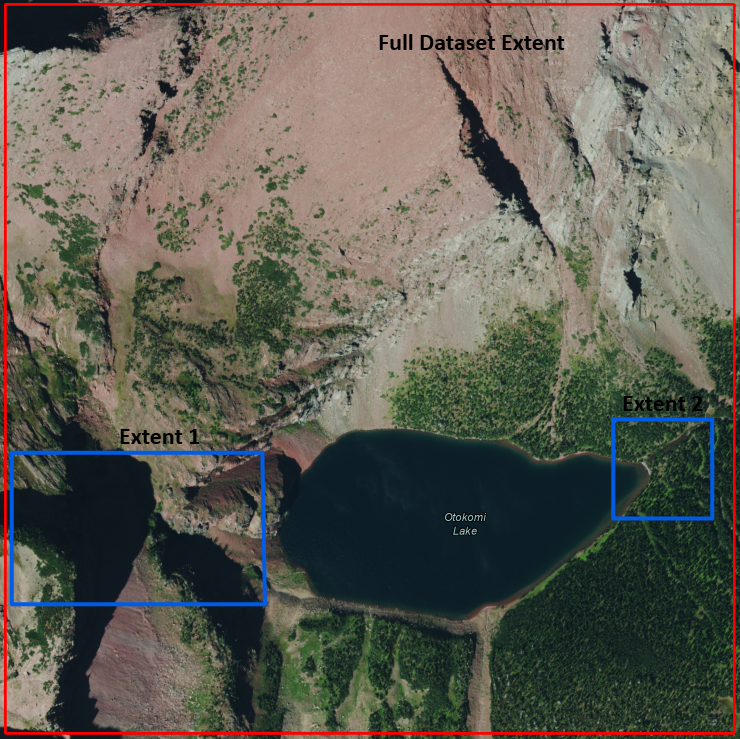

In [ ]:
las<-readLAS("lidar_site.laz", #here is where you would put the full file address for readLAS to access
filter = "-keep_x 298008.69, 298356.147, -keep_y 504177.18, 504385.04" #Extent 1
)


Start by accessing the LAZ file through the lidR package.
The filter argument allows us to reduce initial computation by only targetting specific location or technical components of lidar data like the scan angle. See the link here to see other methods of filtering: [Filtering Options](https://github.com/reblekah/UASLidarWorkshop_SKC_2026/blob/main/Filtering%20Options)

For our purposes today, we are filtering our analysis to two major places. First, we're going to use Extent 1.


We've imported the LAZ file, but "print(las)" will show us what's inside.
First, the dataset is 341 MB, but if we would have imported the whole extent, we would have over 4GB of data. This can be processed but for the most part, breaking it down into smaller pieces is a good idea.
It looks like we have about 5 million points, but there may be some repeats.

In [16]:
print(las)

class        : LAS (v1.4 format 6)
memory       : 341.9 Mb 
extent       : 298008.7, 298356.1, 504177.2, 504385 (xmin, xmax, ymin, ymax)
coord. ref.  : NAD83(2011) / Montana + NAVD88 height - Geoid18 (m) 
area         : 73500 m²
points       : 4.72 million points
type         : airborne
density      : 64.19 points/m²
density      : 60.94 pulses/m²


Let's see how complete the data is by examining the data itself for many common issues in lidar data. According to the documentation:

"For a LAS object it checks:
* if the point cloud is valid according to las specification
* if the header is valid according to las specification
* if the point cloud is in accordance with the header
* if the point cloud has duplicated points and degenerated ground points
* if gpstime and pulses are consistent
* it the coordinate reference sytem is correctly recorded
* if some pre-processing, such as normalization or ground filtering, is already done.
* and much more"


In [17]:
las_check(las)


 Checking the data
  - Checking coordinates... ✓
  - Checking coordinates type... ✓
  - Checking coordinates range... ✓
  - Checking coordinates quantization... ✓
  - Checking attributes type... ✓
  - Checking ReturnNumber validity... ✓
  - Checking NumberOfReturns validity... ✓
  - Checking ReturnNumber vs. NumberOfReturns... ✓
  - Checking RGB validity... ✓
  - Checking absence of NAs... ✓
  - Checking duplicated points...
    ⚠ 2585 points are duplicated and share XYZ coordinates with other points
  - Checking degenerated ground points...
    ⚠ There were 11 degenerated ground points. Some X Y Z coordinates were repeated
    ⚠ There were 1 degenerated ground points. Some X Y coordinates were repeated but with different Z coordinates
  - Checking attribute population...
    🛈 'ScanDirectionFlag' attribute is not populated
  - Checking gpstime incoherances
    ✗ 67501 pulses (points with the same gpstime) have points with identical ReturnNumber
  - Checking flag attributes...
    🛈 5

If you'll notice "Checking duplicate points" has found that 2585  points have matching coordinates with other points. Additionally, there are some degenerated ground points which we will filter out later.
This isn't uncommon in lidar data, so let's drop those.

In [18]:
las_clean<-filter_duplicates(las)

Let's remove our original data, we can always access again if we need to. We're doing this to keep our working environment tidy but also making sure we don't run into processing caps Google Colab puts in place.

Remember, this code is just a sample and there are ways to manage large datasets. I would be happy to help make recommendations or provide support if you need.

In [ ]:
rm(las) #remove the original lidar file - we can always get it back!
gc() #clear out some of Colab's unused memory

##Examining our dataset

We've filtered our point data to prevent duplicates, but what does the data even look like?

Las/Laz files contain attributes for all points within a point cloud. Those attributes typically contain the X, Y, and Z coordinates, Intensity, any reflectance data if collected as well as returns, scan directions, gps time etc.
We will work our way through some of this data, but for now, let's just look at the data temporarily in a dataframe or table.

In [18]:
head(las_clean@data)

X,Y,Z,gpstime,Intensity,ReturnNumber,NumberOfReturns,ScanDirectionFlag,EdgeOfFlightline,Classification,ScannerChannel,Synthetic_flag,Keypoint_flag,Withheld_flag,Overlap_flag,ScanAngle,UserData,PointSourceID
<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<int>,<int>
298023.8,504737.3,2278.95,283444247,42685,1,1,0,0,2,1,FALSE,FALSE,FALSE,FALSE,28.002,1,1036
298023.1,504737.1,2279.44,283444247,46180,1,1,0,0,1,1,FALSE,FALSE,TRUE,FALSE,28.002,1,1036
298022.5,504737.0,2279.62,283444247,47906,1,1,0,0,1,1,FALSE,FALSE,TRUE,FALSE,28.002,1,1036
298022.0,504736.9,2279.66,283444247,49762,1,1,0,0,1,1,FALSE,FALSE,TRUE,FALSE,28.002,1,1036
298021.8,504736.9,2279.24,283444247,47512,1,1,0,0,2,1,FALSE,FALSE,TRUE,FALSE,28.002,1,1036
298021.4,504736.8,2279.21,283444247,43340,2,2,0,0,1,1,FALSE,FALSE,TRUE,FALSE,28.002,1,1036


Point clouds are not easily visualized in Google Colab unfortunately, but we can visualize some cross sections instead.

In [8]:
file_id <- "1Pqhu2O0g_JJihOFI7jEsbgLWjeX3besP" #Actual link to shared file: https://drive.google.com/file/d/1Pqhu2O0g_JJihOFI7jEsbgLWjeX3besP/view?usp=sharing
public_file <- drive_get(as_id(file_id))
drive_download(public_file, path = "FilteringPolygons.zip", overwrite = TRUE)
unzip("FilteringPolygons.zip")
Filter_poly<-sf::st_read("FilteringPolygons.shp")
Extent1<-Filter_poly[1, ]
print(ext(Extent1))

File downloaded:

• FilteringPolygons.zip <id: 1Pqhu2O0g_JJihOFI7jEsbgLWjeX3besP>

Saved locally as:

• FilteringPolygons.zip



Reading layer `FilteringPolygons' from data source 
  `/content/FilteringPolygons.shp' using driver `ESRI Shapefile'
Simple feature collection with 2 features and 7 fields
Geometry type: POLYGON
Dimension:     XYZ
Bounding box:  xmin: 298008.7 ymin: 504177.2 xmax: 298969.8 ymax: 504430.5
z_range:       zmin: 0 zmax: 0
Projected CRS: NAD83(2011) / Montana
SpatExtent : 298008.696800001, 298356.147799999, 504177.1807, 504385.039500002 (xmin, xmax, ymin, ymax)


Warning message in viridisLite::viridis(n, alpha, begin, end, direction, option):
“Option 'terrain' does not exist. Defaulting to 'viridis'.”


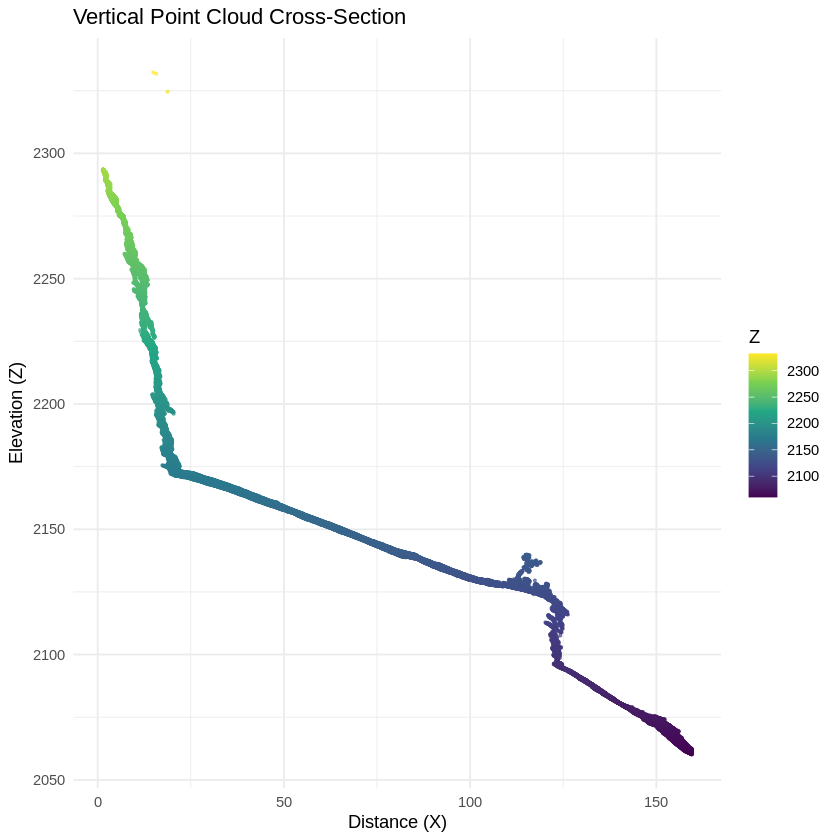

In [12]:
p1 <- c(298100, 504200) # c(x, y)
p2 <- c(298250, 504250) #feel free to change p1 or p2 to any points within our SpatExtent shown above to look at other cross sections.
las_tr <- clip_transect(las_clean, p1, p2, width =5, xz = TRUE)

ggplot(payload(las_tr), aes(x = X, y = Z, color = Z)) +
  geom_point(size = 0.5, alpha = 0.6) +
  coord_equal()+
  scale_color_viridis_c(option = "terrain") +
  labs(title = "Vertical Point Cloud Cross-Section", x = "Distance (X)", y = "Elevation (Z)") +
  theme_minimal()

Below is the location of the cross-section we plotted.

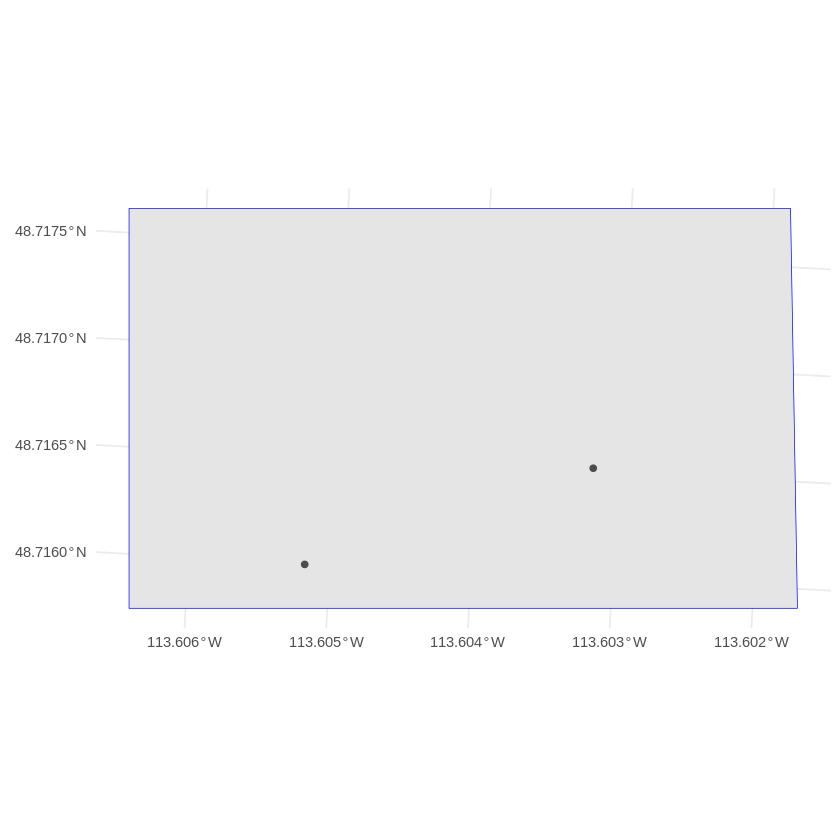

In [13]:
crosssection<- as.data.frame(rbind(p1,p2))
colnames(crosssection)<-c("lat", "long")
crosspoints<- st_as_sf(crosssection, coords = c("lat", "long"),crs=st_crs(Filter_poly))

ggplot()+
  geom_sf(data = Extent1, color = "Blue")+
  geom_sf(data = crosspoints, color = "Grey30")+
  theme_minimal()

##More advanced surface generation

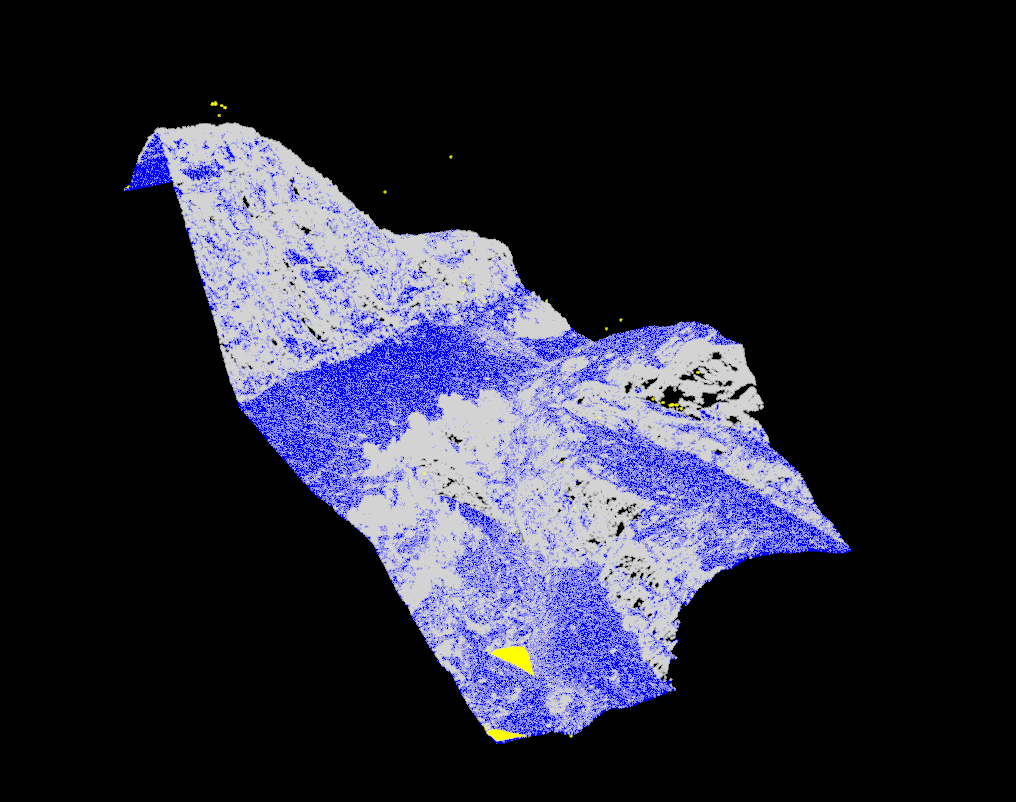

Above is a 3D representation of the area we're mapping. Unfortunately Google Colab does not have 3D mapping capabilities, but hopefully this visualization helps you see what we're working with.
The grey, blue, and yellow colors all represent different classifications of point data, grey is unclassified, blue is ground, yellow are errors, noise or potentially vegetation.

A common use of lidar data is to generate digital surface or digital terrain models. This is fairly easy to do using the lidR package.

Original dataset already contains 2880303 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.



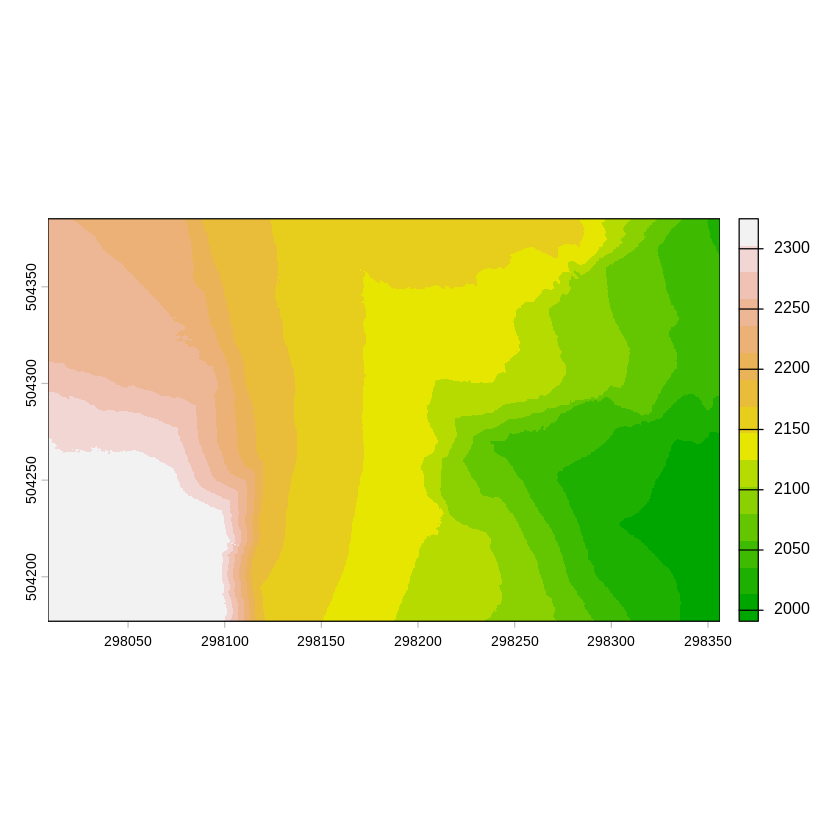

In [21]:
mycsf <- csf(TRUE, 0.5, 0.5, time_step = 0.65) #this is an algorithm to select ground points based on a handful of variable inputs.
las_clean <- classify_ground(las_clean, mycsf)

plot(rasterize_terrain(las_clean, res=0.2,use_class = 2), col=terrain.colors(15))

What the graph above shows us is a rough DTM. We used a k-nearest neighbor algorithm which checks "k" nearby points and weighs them to determine each pixel's value. This is a functional algorithm for our purposes, but there are many ways to separate ground, vegetation, water, and more.

The algorithm I've chosen is simply for speed, but there are many smart people who have been developing these methods for decades that have specific use cases. We uses the Cloth Simulation Filter which flips our dataset over and "drapes" a cloth on top to find the surface and generate a digital terrain model (DTM). This is a good method to use in areas with complex topography.

In [27]:
writeRaster(rasterize_terrain(las_clean,res=1,use_class = 2), "DTM_Ext1.tif")


We can finally export that raster at a 1m resolution. This function automatically stores it in your local files to the left of the screen. You can download that .tif file directly to your personal files.
In order to convert the las file, you must use "rasterize_terrain" which selects our class (ground = class 2) and converts the point cloud to a raster based on the resolution you select.

#Canopies and more complex algorithms.

Now we're going to use the lidR package to identify tree tops. Since our first extent had limited trees, we are going to move to a new spot.

In [28]:
rm(las_clean)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5410890,289.0,9068868,484.4,9068868,484.4
Vcells,8591054,65.6,167401172,1277.2,510578315,3895.5


In [29]:
Extent2<-Filter_poly[2, ]
print(ext(Extent2))

SpatExtent : 298833.952600002, 298969.7522, 504294.738600001, 504430.538199998 (xmin, xmax, ymin, ymax)


In [30]:
las<-readLAS("lidar_site.laz", #here is where you would put the full file address for readLAS to access
filter = "-keep_x 298833.95, 298969.75, -keep_y 504294.73, 504430.53" #Extent 2
)
print(las)

Warning message:
“There are 5 points flagged 'withheld'.”


class        : LAS (v1.4 format 6)
memory       : 89.6 Mb 
extent       : 298834, 298969.7, 504294.7, 504430.5 (xmin, xmax, ymin, ymax)
coord. ref.  : NAD83(2011) / Montana + NAVD88 height - Geoid18 (m) 
area         : 18956 m²
points       : 1.24 million points
type         : airborne
density      : 65.22 points/m²
density      : 51.65 pulses/m²


In [31]:
las_check(las)


 Checking the data
  - Checking coordinates... ✓
  - Checking coordinates type... ✓
  - Checking coordinates range... ✓
  - Checking coordinates quantization... ✓
  - Checking attributes type... ✓
  - Checking ReturnNumber validity... ✓
  - Checking NumberOfReturns validity... ✓
  - Checking ReturnNumber vs. NumberOfReturns... ✓
  - Checking RGB validity... ✓
  - Checking absence of NAs... ✓
  - Checking duplicated points...
    ⚠ 357 points are duplicated and share XYZ coordinates with other points
  - Checking degenerated ground points...
    ⚠ There were 2 degenerated ground points. Some X Y Z coordinates were repeated
  - Checking attribute population...
    🛈 'ScanDirectionFlag' attribute is not populated
  - Checking gpstime incoherances ✓
  - Checking flag attributes...
    🛈 5 points flagged 'withheld'
  - Checking user data attribute...
    🛈 1236310 points have a non 0 UserData attribute. This probably has a meaning
 Checking the header
  - Checking header completeness... ✓


In [34]:
las_clean<- filter_duplicates(las)

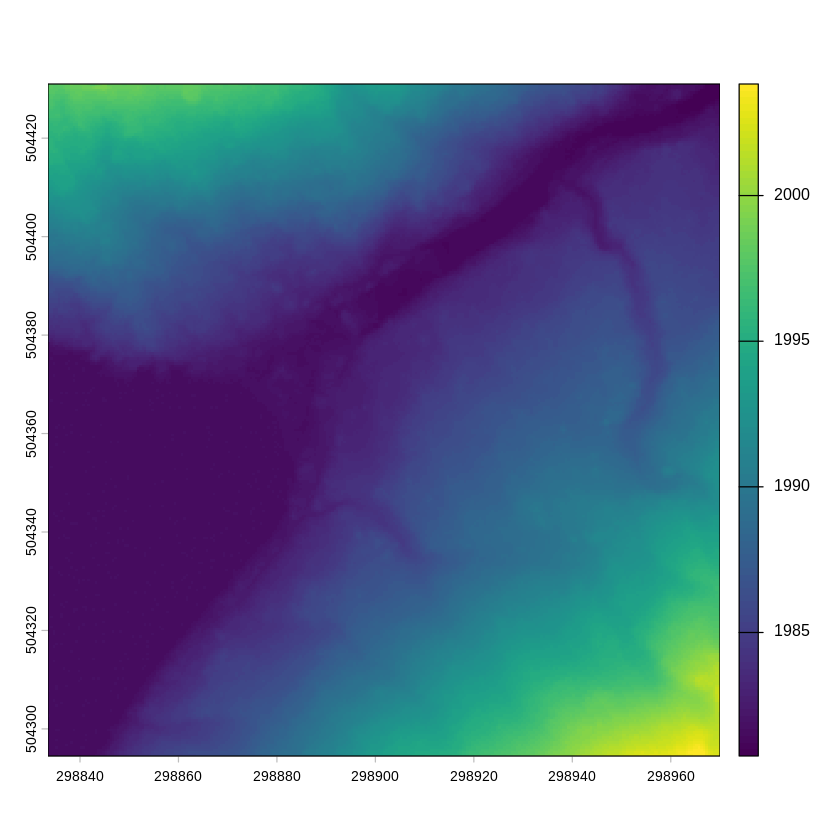

In [36]:
plot(rasterize_terrain(las_clean, res=0.5))

Here's a visualization of our second extent.
What do you notice?

Let's look at this data in a different way.

In [57]:
cloud_metrics(las_clean, .stdmetrics_i) #cloud metrics computes a variety of common statistics for our datasets. Let's look at our intensity values first.

$itot
[1] 51809296267

$imax
[1] 64508

$imean
[1] 41918.5

$isd
[1] 8622.576

$iskew
[1] -1.081068

$ikurt
[1] 3.196687

$ipground
[1] 59.23246

$ipcumzq10
[1] 9.300916

$ipcumzq30
[1] 30.87676

$ipcumzq50
[1] 51.40781

$ipcumzq70
[1] 71.20348

$ipcumzq90
[1] 90.63796

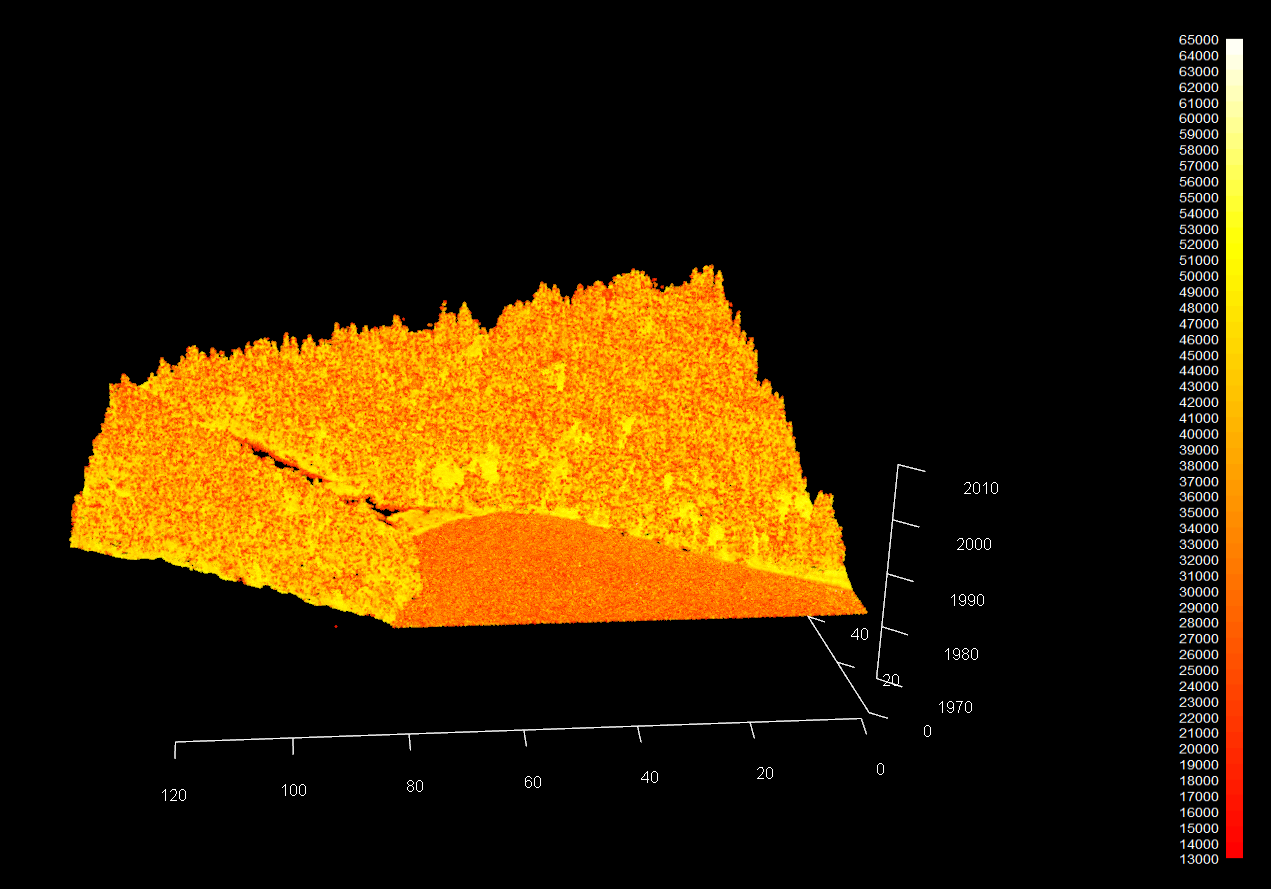

By looking at our intensity values against our Z (height), we can see the low elevation areas that we can see are water, are also classified with a lower intensity value. Let's see if we can filter the water and the ground from the trees.


Classes

1: Unassigned

2: Ground

7: Low Point (noise)

9: Water

18: High Noise

20: Unknown


In [53]:
las_clean$Classification<-as.factor(las_clean$Classification)
table(las_clean$Classification)


     1      2      7      9     18     20 
843882 346944      3  42962      2   2160 

Let's progressively classify our data.

In [54]:
las_clean<-classify_ground(las_clean, mycsf)
table(las_clean$Classification)

Original dataset already contains 346944 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.




     1      2      7      9     18     20 
540507 695437      3      0      2      4 

Notice how we were able to reclassify our points. We lost a lot of our water classified points which means we need to reclassify our water.

To do this, we're going to progressively filter our water from our vegetation.

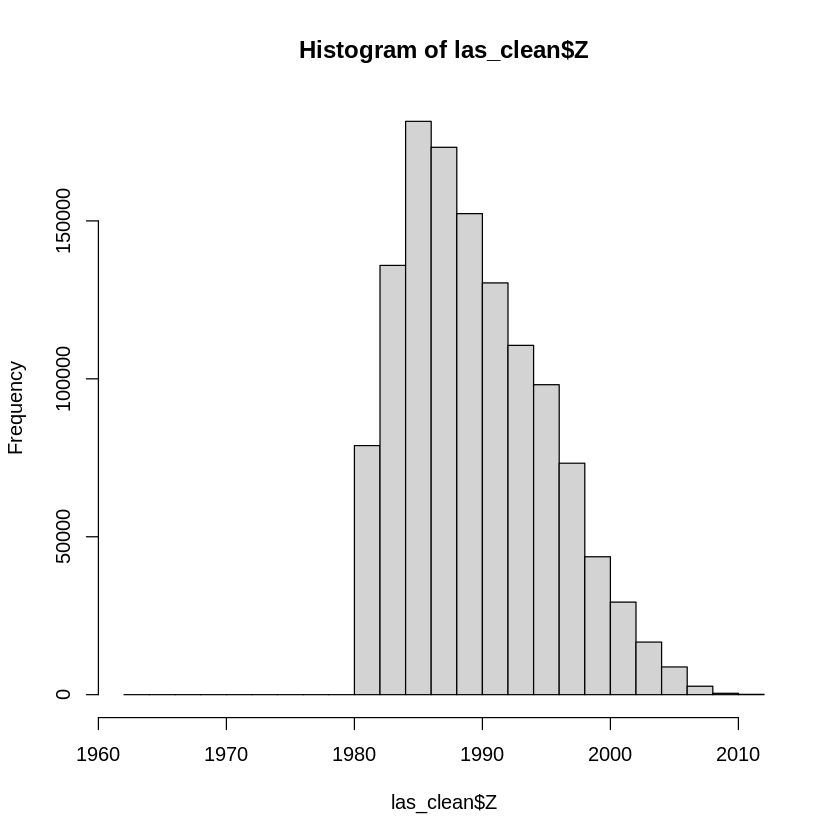

In [55]:
hist(las_clean$Z)